In [11]:
# Exercise 4:
# Task 1
import numpy as np
import pandas as pd

arr = np.ones((5, 5))  # Creating 5x5 matrix
arr[1:4, 1:4] = 0  # setting the interior to  zero
print(arr)


# Task 2: Normalize a random array
# (5 points)
np.random.seed(42)
random_data = np.random.randn(100, 3)
# Normalize each column to have mean=0 and std=1
normalized_form = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print(normalized_form)


X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# STEP 1: Add bias term (column of 1s)
X_b = np.c_[np.ones((50, 1)), X]  # shape becomes (50, 4)

# STEP 2: Compute theta using normal equation
theta_hat = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

# STEP 3: Print results
print("Estimated theta:", theta_hat)
print("True theta (with intercept 0):", np.r_[0, true_theta])

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
[[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-01]
 [-5.81051242e-01 -5.06767212e-01  4.84818

In [12]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""
import pandas as pd
import numpy as np

# Creating a sample dataset
np.random.seed(42)
n_students = 200

data = {
    "student_id": range(1000, 1000 + n_students),
    "major": np.random.choice(["CS", "Math", "Physics", "Biology"], n_students),
    "year": np.random.choice([1, 2, 3, 4], n_students),
    "exam_score": np.random.normal(75, 10, n_students).clip(0, 100),
    "assignments_completed": np.random.randint(0, 11, n_students),
    "hours_studied": np.random.normal(15, 5, n_students).clip(1, 40),
}
df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), "exam_score"] = np.nan
df.loc[np.random.choice(n_students, 5), "hours_studied"] = np.nan

# Task 1
# Displaying basic information about dataset
print(df.info())

# Identify and count missing values
print(df.isnull().sum())

##  Fill missing exam_score with the mean score for the student's major
df["exam_score"] = df["exam_score"].fillna(
    df.groupby("major")["exam_score"].transform("mean")
)

# Fill missing hours_studied with the median for the student's year
df["hours_studied"] = df["hours_studied"].fillna(
    df.groupby("year")["hours_studied"].transform("median")
)


# Task 2
# Calculate and display the average exam_score by major
print(df.groupby("major")["exam_score"].agg(["mean"]))

# Find major with the highest average exam_score
# Major with highest average exam_score
avrg_by_major = df.groupby("major")["exam_score"].mean()

top_major = avrg_by_major.idxmax()
top_score = avrg_by_major.max()
print("Top Major:", top_major)
print("Average Score:", top_score)

# Calculate the correlation between hours_studied and exam_score
print(df["hours_studied"].corr(df["exam_score"]))

# Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
columnCat = [
    df["exam_score"] > 90,
    (df["exam_score"] >= 80) & (df["exam_score"] <= 90),
    (df["exam_score"] >= 70) & (df["exam_score"] < 80),
    df["exam_score"] < 70,
]

ScoreInterp = ["Excellent", "Good", "Average", "Needs Improvement"]

df["performance"] = np.select(columnCat, ScoreInterp, default="Unknown")


# Task 3
# For each major and year combination, calculate: Number of students, Average exam score, Average hours studied
#  
summary = df.groupby(["major", "year"]).agg(
    student_count=("student_id", "count"),
    avg_exam_score=("exam_score", "mean"),
    avg_hours_studied=("hours_studied", "mean"),
)


print(summary)

# Identify top 5 students based on exam_score
top_score = df["exam_score"].nlargest(5).min()

top_students = df[df["exam_score"] >= top_score]

print(top_students)
# Create a pivot table showing average exam_score by major (rows) and year (columns)
studpivot = df.pivot_table(
    values="exam_score", index="major", columns="year", aggfunc="mean"
)

print(studpivot)

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64
              mean
major             
Biology  75.503150
CS       76.425184
Math     74.683689
Physics  75.406509
Top Major: CS
Average Score: 76.42518387979709
-0.05598138347292447
              student_count  avg_exam_score  avg_hours_

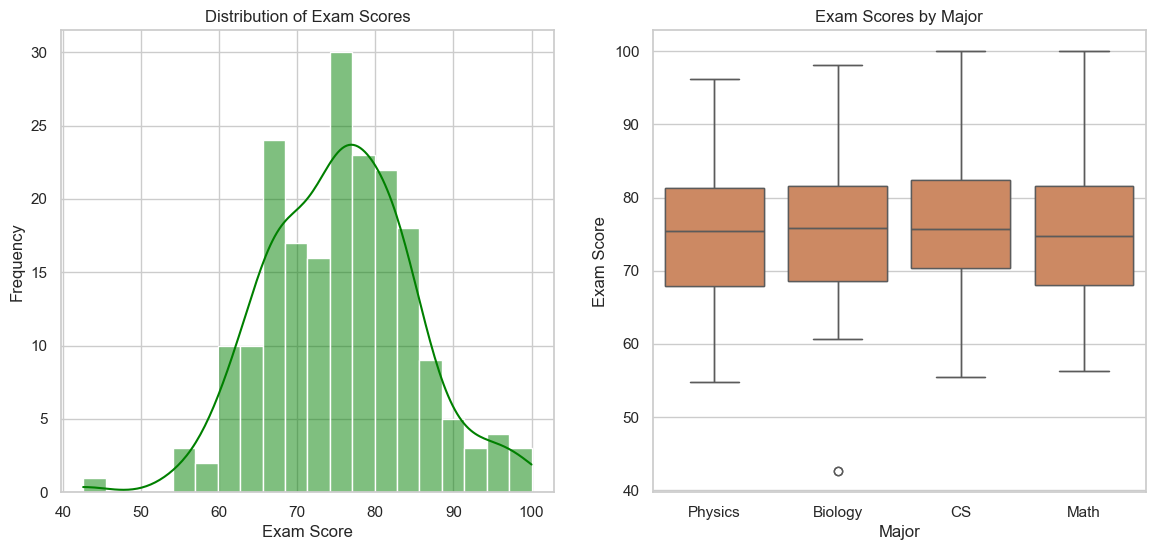

<Figure size 1000x600 with 0 Axes>

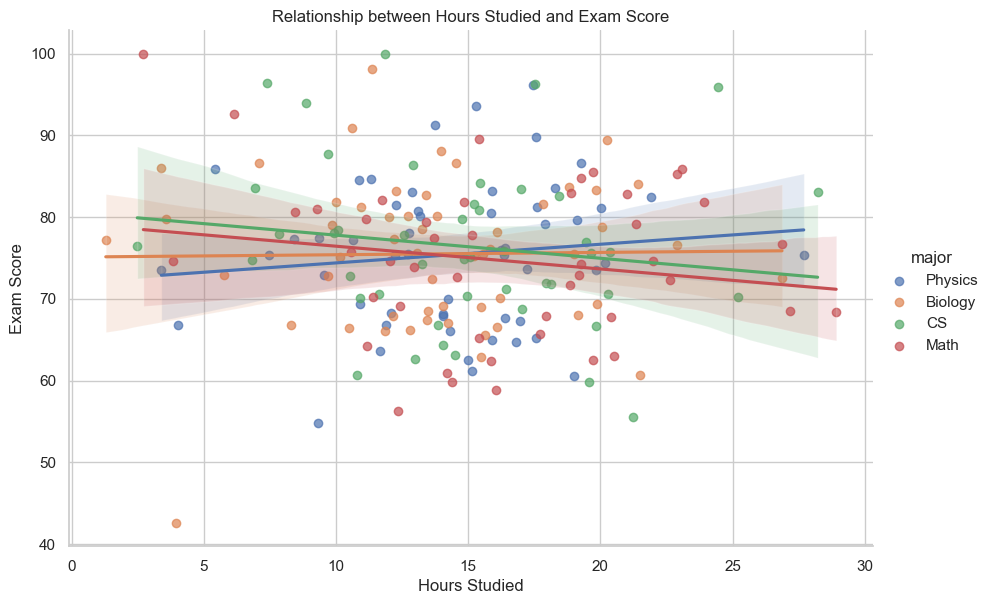

C:\Users\Prince\AppData\Local\Temp\ipykernel_8768\2286978655.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="year", ax=axes[0, 1], palette="Set2")
C:\Users\Prince\AppData\Local\Temp\ipykernel_8768\2286978655.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


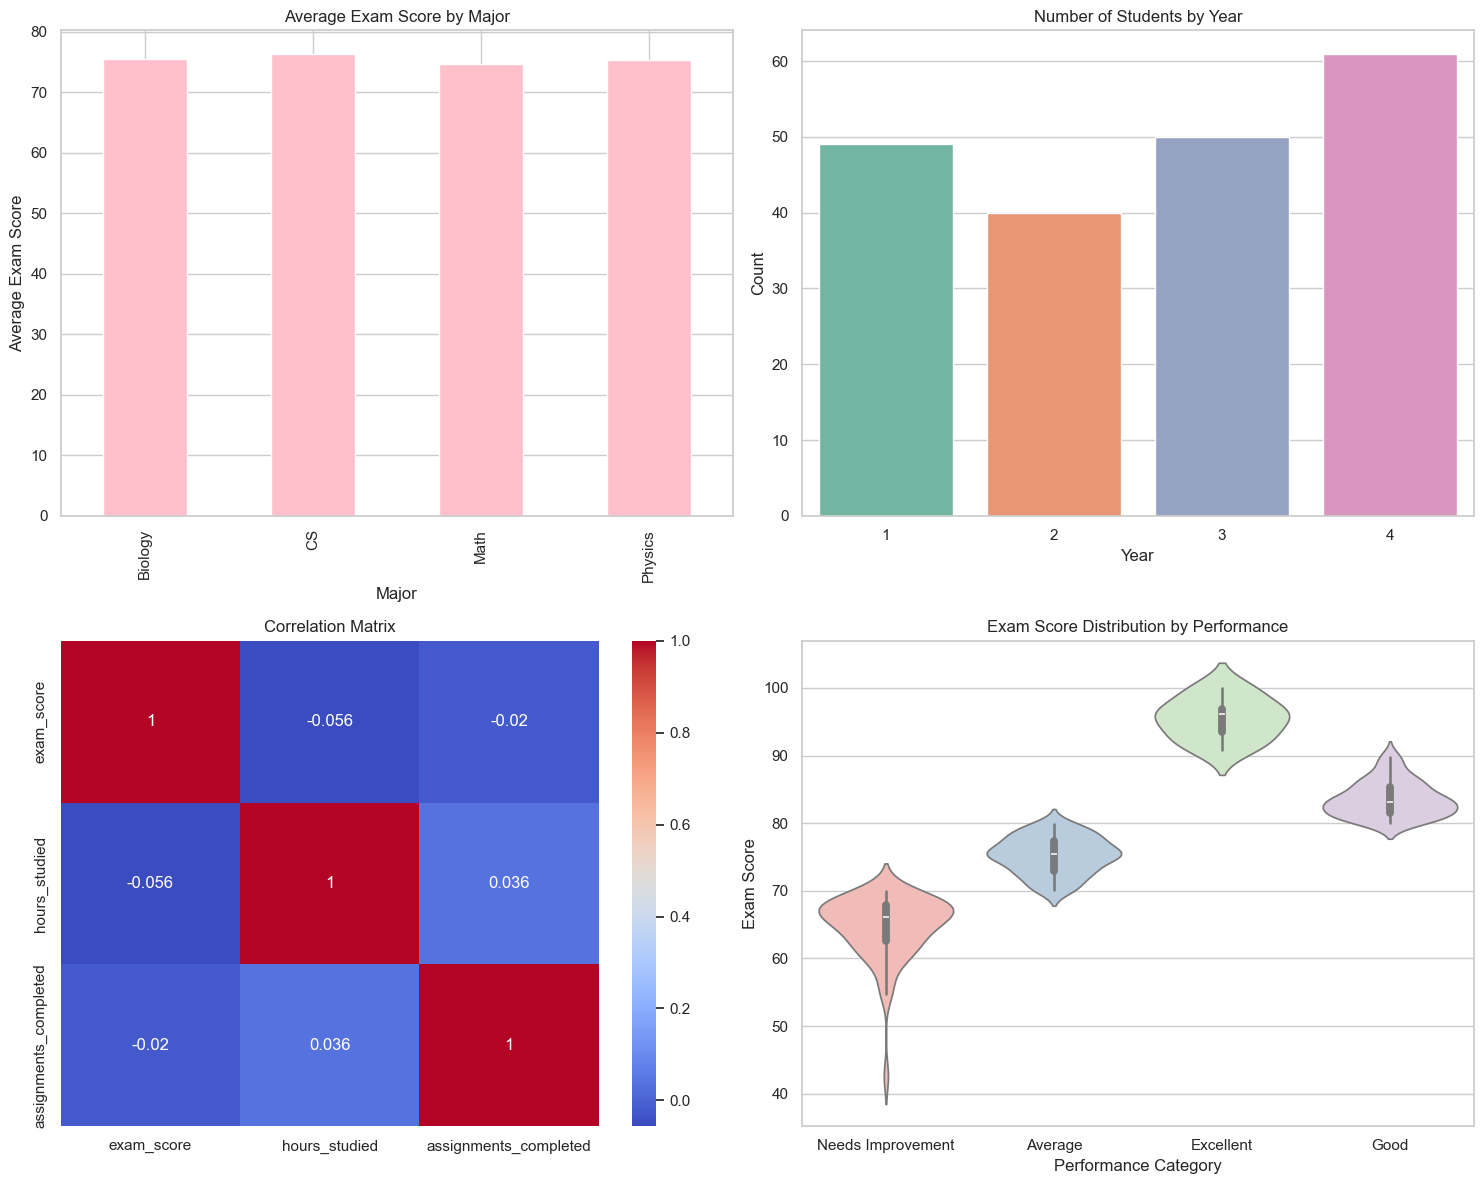

In [13]:
# Exervise 6: Data Visualization
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""
# Task 1
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))


plt.subplot(1, 2, 1)
sns.histplot(df["exam_score"], kde=True, bins=20, color="green")

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")


plt.subplot(1, 2, 2)
sns.boxplot(x="major", y="exam_score", data=df)

plt.title("Exam Scores by Major")
plt.xlabel("Major")
plt.ylabel("Exam Score")
plt.subplot(1, 2, 2)
sns.boxplot(x="major", y="exam_score", data=df)

plt.title("Exam Scores by Major")
plt.xlabel("Major")
plt.ylabel("Exam Score")


# Task 2
# Scatter with regression line


plt.figure(figsize=(10, 6))

sns.set(style="whitegrid")

#### Scatter plot with regression line + color by major
sns.lmplot(
    data=df,
    x="hours_studied",
    y="exam_score",
    hue="major",
    height=6,
    aspect=1.5,
    scatter_kws={"alpha": 0.7},
)


plt.title("Relationship between Hours Studied and Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()

####Task 3
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

avrg_major = df.groupby("major")["exam_score"].mean()

avrg_major.plot(kind="bar", ax=axes[0, 0], color="pink")
axes[0, 0].set_title("Average Exam Score by Major")
axes[0, 0].set_xlabel("Major")
axes[0, 0].set_ylabel("Average Exam Score")

sns.countplot(data=df, x="year", ax=axes[0, 1], palette="Set2")

axes[0, 1].set_title("Number of Students by Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Count")

correl = df[["exam_score", "hours_studied", "assignments_completed"]].corr()

sns.heatmap(correl, annot=True, cmap="coolwarm", ax=axes[1, 0])

axes[1, 0].set_title("Correlation Matrix")


sns.violinplot(
    data=df, x="performance", y="exam_score", ax=axes[1, 1], palette="Pastel1"
)

axes[1, 1].set_title("Exam Score Distribution by Performance")
axes[1, 1].set_xlabel("Performance Category")
axes[1, 1].set_ylabel("Exam Score")

plt.tight_layout()
plt.show()

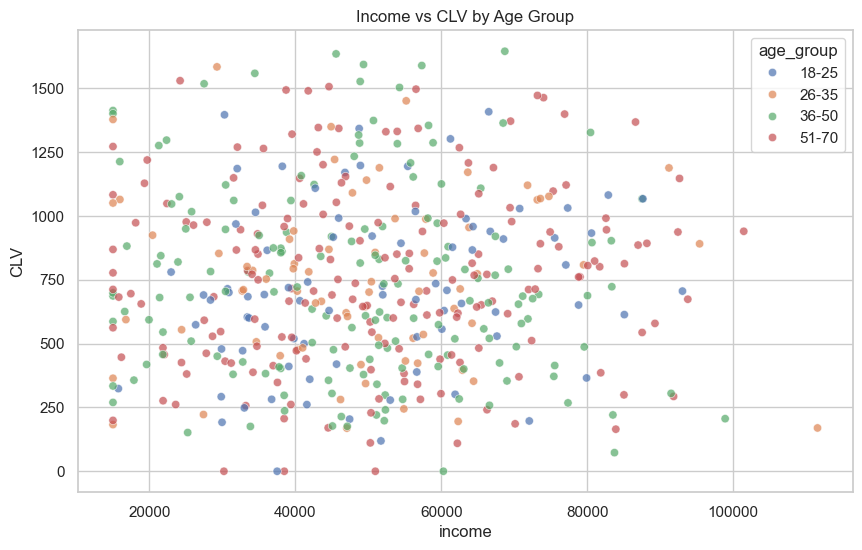

C:\Users\Prince\AppData\Local\Temp\ipykernel_8768\3281152532.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avrg_clv.index, y=avrg_clv.values, palette="viridis")


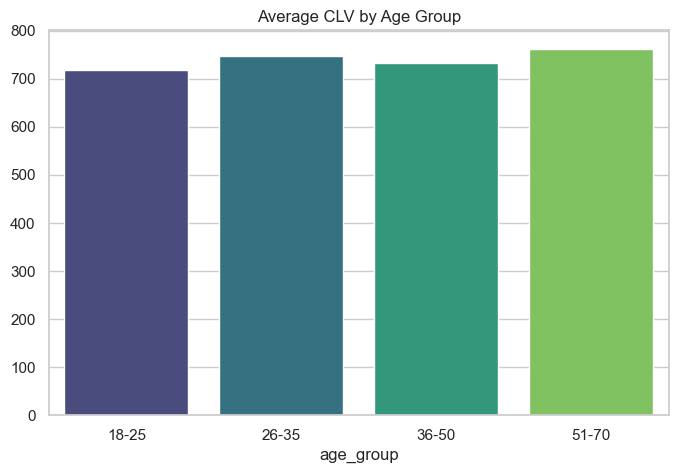

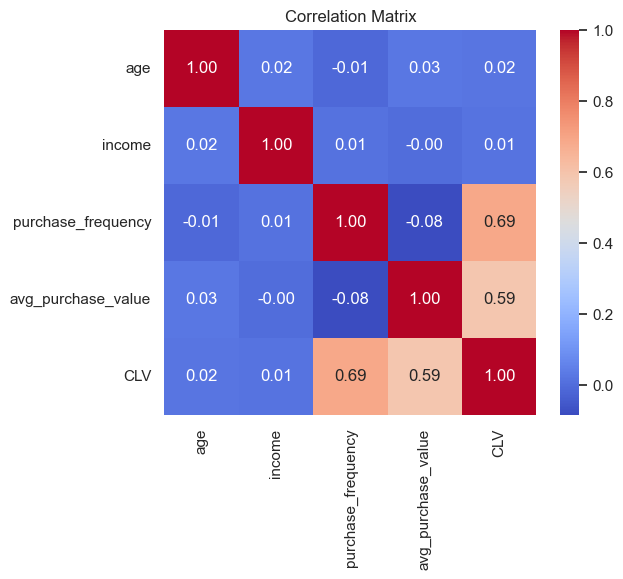

'The analysis shows that customer lifetime value (CLV) is influenced by both purchase frequency and average purchase value. Analytically, Customers with higher engagement levels tend to generate higher CLV, elightening the importance of repeat purchasing behavior.\nAge group analysis indicates that customers between 26–50 years contribute the highest overall CLV, suggesting they represent the most valuable segment of the customer base. Income also shows a positive relationship with CLV, meaning higher-income customers tend to spend more.\nThe top 10% of customers contribute a very large share of total CLV, emphasizing the need for retention strategies with targets.'

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


np.random.seed(42)
n_customers = 500

###### Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avrg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

##### Create DataFrame
customers = pd.DataFrame(
    {
        "age": ages,
        "income": income,
        "purchase_frequency": purchase_freq,
        "avg_purchase_value": avrg_purchase_value,
    }
)


#####capute CLV
df = customers.copy()

max_freq = df["purchase_frequency"].max()

df["churn_risk"] = 1 - (df["purchase_frequency"] / max_freq)

df["CLV"] = df["purchase_frequency"] * df["avg_purchase_value"] * (1 + df["churn_risk"])


######Age Group
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 25, 35, 50, 70],
    labels=["18-25", "26-35", "36-50", "51-70"],
    include_lowest=True,
)


##### Age summary
age_summary1 = df.groupby("age_group").agg(
    customer_count=("age", "count"),
    avg_income=("income", "mean"),
    avg_clv=("CLV", "mean"),
    total_clv=("CLV", "sum"),
)

age_summary1


###Top 10% customers by CLV
threshold = df["CLV"].quantile(0.90)

top_customers = df[df["CLV"] >= threshold]

top_customers


####


plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="income", y="CLV", hue="age_group", alpha=0.7)

plt.title("Income vs CLV by Age Group")
plt.show()


###Average CLV by  Age group


avrg_clv = df.groupby("age_group")["CLV"].mean().sort_values()

plt.figure(figsize=(8, 5))

sns.barplot(x=avrg_clv.index, y=avrg_clv.values, palette="viridis")

plt.title("Average CLV by Age Group")
plt.show()


######Correlation HeatMap
plt.figure(figsize=(6, 5))

sns.heatmap(
    df[["age", "income", "purchase_frequency", "avg_purchase_value", "CLV"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)

plt.title("Correlation Matrix")
plt.show()


"""The analysis shows that customer lifetime value (CLV) is influenced by both purchase frequency and average purchase value. Analytically, Customers with higher engagement levels tend to generate higher CLV, elightening the importance of repeat purchasing behavior.
Age group analysis indicates that customers between 26–50 years contribute the highest overall CLV, suggesting they represent the most valuable segment of the customer base. Income also shows a positive relationship with CLV, meaning higher-income customers tend to spend more.
The top 10% of customers contribute a very large share of total CLV, emphasizing the need for retention strategies with targets."""